In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
voi= pd.read_csv("../data/df_all_voi.csv")

In [3]:
voi = voi.rename(columns={
    "Lat inizio corsa_coordinate": "start_lat",
    "Lon inizio corsa_coordinate": "start_lon",
    "Lat fine corsa_coordinate": "end_lat",
    "Lon fine corsa_coordinate": "end_lon",
    "Data inizio corsa": "start_time",
    "Data fine corsa": "end_time"
})


In [4]:
voi["start_time"] = pd.to_datetime(voi["start_time"])
voi["end_time"]   = pd.to_datetime(voi["end_time"])

In [5]:
print("\nVoi columns:\n", voi.columns)


Voi columns:
 Index(['Identificativo noleggio', 'Targa veicolo', 'start_time', 'end_time',
       'start_lat', 'start_lon', 'end_lat', 'end_lon', 'Tempo Tot', 'KM Tot',
       'Prenotazione', 'Batteria inizio', 'Batteria fine', 'source_file',
       'start_hour', 'start_date', 'weekday', 'is_weekend', 'duration_hours',
       'speed_kmh', 'trip_date', 'year', 'hour', 'month', 'week'],
      dtype='str')


In [6]:
voi = voi.sort_values(by=['Targa veicolo', 'start_time'])

In [7]:
voi[['Targa veicolo', 'start_time', 'end_time']].head(20)

,Targa veicolo,start_time,end_time
239929,224g,2024-04-09 18:56:55,2024-04-09 19:02:39
239259,224g,2024-04-12 06:28:57,2024-04-12 06:34:43
239187,224g,2024-04-12 11:41:14,2024-04-12 12:45:59
238155,224g,2024-04-14 20:44:35,2024-04-14 20:50:39
238063,224g,2024-04-15 06:28:52,2024-04-15 06:38:58
236913,224g,2024-04-18 18:50:22,2024-04-18 18:59:40
236858,224g,2024-04-18 22:33:59,2024-04-18 22:36:55
236789,224g,2024-04-19 08:13:49,2024-04-19 08:20:20
236248,224g,2024-04-20 19:41:16,2024-04-20 19:56:54
235591,224g,2024-04-23 19:45:49,2024-04-23 19:53:36


In [8]:
voi['start_time'].min(), voi['start_time'].max()

(Timestamp('2024-01-31 23:03:35'), Timestamp('2025-10-31 22:56:24'))

In [9]:
voi.sort_values(by='start_time').head(20)

,Identificativo noleggio,Targa veicolo,start_time,end_time,start_lat,start_lon,end_lat,end_lon,Tempo Tot,KM Tot,...,start_date,weekday,is_weekend,duration_hours,speed_kmh,trip_date,year,hour,month,week
147836,c8165abf-fe8c-47e9-938d-085686fc6d96,q9cs,2024-01-31 23:03:35,2024-01-31 23:18:59,45.040992,7.653678,45.067175,7.641245,15.400000,3.070845,...,2024-01-31,2.0,False,0.256667,11.964332,2024-01-31,2024.0,23.0,1.0,5.0
147834,dc35760d-37c7-4866-94a9-81000213f6ef,st25,2024-01-31 23:11:18,2024-01-31 23:13:10,45.058156,7.659958,45.055701,7.664412,1.866667,0.443684,...,2024-01-31,2.0,False,0.031111,14.261264,2024-01-31,2024.0,23.0,1.0,5.0
147835,dc35760d-37c7-4866-94a9-81000213f6ef,st25,2024-01-31 23:11:18,2024-01-31 23:13:10,45.058156,7.659958,45.055701,7.664412,1.866667,0.443684,...,2024-01-31,2.0,False,0.031111,14.261264,2024-01-31,2024.0,23.0,1.0,5.0
147833,dc35760d-37c7-4866-94a9-81000213f6ef,st25,2024-01-31 23:11:18,2024-01-31 23:13:10,45.058156,7.659958,45.055701,7.664412,1.866667,0.443684,...,2024-01-31,2.0,False,0.031111,14.261264,2024-01-31,2024.0,23.0,1.0,5.0
147832,29f3cb83-f696-472e-8964-ed5dd965ef52,lxqm,2024-01-31 23:14:48,2024-01-31 23:23:06,45.063897,7.681265,45.074343,7.672906,8.300000,1.334275,...,2024-01-31,2.0,False,0.138333,9.645359,2024-01-31,2024.0,23.0,1.0,5.0
147831,2d5f0fc4-d028-4cb6-ad19-a5b17e3eb1da,gdks,2024-01-31 23:16:49,2024-01-31 23:29:28,45.050152,7.668371,45.065572,7.655766,12.650000,1.979972,...,2024-01-31,2.0,False,0.210833,9.391173,2024-01-31,2024.0,23.0,1.0,5.0
147830,dae7385b-2624-4411-a11c-41cbefe78b56,u66y,2024-01-31 23:17:28,2024-01-31 23:26:08,45.058327,7.656713,45.042571,7.643101,8.666667,2.052568,...,2024-01-31,2.0,False,0.144444,14.210089,2024-01-31,2024.0,23.0,1.0,5.0
147829,5439ccb8-ceb1-482c-ace6-4ce65aa555c3,3gby,2024-01-31 23:22:13,2024-01-31 23:25:49,45.036944,7.646866,45.039538,7.654180,3.600000,0.643043,...,2024-01-31,2.0,False,0.060000,10.717378,2024-01-31,2024.0,23.0,1.0,5.0
147828,d2ecac2c-6797-47e8-88b4-209bbb9e2393,sqgg,2024-01-31 23:28:16,2024-01-31 23:39:49,45.077583,7.681681,45.061501,7.658390,11.550000,2.558000,...,2024-01-31,2.0,False,0.192500,13.288314,2024-01-31,2024.0,23.0,1.0,5.0
147827,8dfed349-9f6f-4437-9726-2fd99d351425,tthu,2024-01-31 23:56:04,2024-02-01 00:02:06,45.056643,7.653207,45.066749,7.656775,6.033333,1.158228,...,2024-01-31,2.0,False,0.100556,11.518289,2024-01-31,2024.0,23.0,1.0,5.0


In [10]:
voi['next_start_time'] = voi.groupby('Targa veicolo')['start_time'].shift(-1)

voi['parking_duration'] = voi['next_start_time'] - voi['end_time']

In [11]:
voi['parking_minutes'] = voi['parking_duration'].dt.total_seconds() / 60

In [12]:
voi[['Targa veicolo', 'end_time', 'next_start_time', 'parking_minutes']].head(20)

,Targa veicolo,end_time,next_start_time,parking_minutes
239929,224g,2024-04-09 19:02:39,2024-04-12 06:28:57,3566.300000
239259,224g,2024-04-12 06:34:43,2024-04-12 11:41:14,306.516667
239187,224g,2024-04-12 12:45:59,2024-04-14 20:44:35,3358.600000
238155,224g,2024-04-14 20:50:39,2024-04-15 06:28:52,578.216667
238063,224g,2024-04-15 06:38:58,2024-04-18 18:50:22,5051.400000
236913,224g,2024-04-18 18:59:40,2024-04-18 22:33:59,214.316667
236858,224g,2024-04-18 22:36:55,2024-04-19 08:13:49,576.900000
236789,224g,2024-04-19 08:20:20,2024-04-20 19:41:16,2120.933333
236248,224g,2024-04-20 19:56:54,2024-04-23 19:45:49,4308.916667
235591,224g,2024-04-23 19:53:36,2024-04-26 17:59:05,4205.483333


In [13]:
voi_clean = voi[
    (voi['parking_minutes'] > 0) & 
    (voi['parking_minutes'] < 10000)
]

In [14]:
from shapely.geometry import Point

voi_clean['geometry'] = voi_clean.apply(
    lambda row: Point(float(row['end_lon']), float(row['end_lat'])),
    axis=1
)

voi_gdf = gpd.GeoDataFrame(voi_clean, geometry='geometry', crs='EPSG:4326')

In [15]:
zones = gpd.read_file("/Users/mina/Desktop/EX4/Turin_Zone.gpkg")

In [16]:
zones = zones.to_crs(voi_gdf.crs)

In [17]:
voi_zones = gpd.sjoin(voi_gdf, zones, how='left', predicate='within')

In [18]:
voi_zones.head()

,Identificativo noleggio,Targa veicolo,start_time,end_time,start_lat,start_lon,end_lat,end_lon,Tempo Tot,KM Tot,...,hour,month,week,next_start_time,parking_duration,parking_minutes,geometry,index_right,ZONASTAT,DENOM
239929,125ead7d-09cc-4f66-afbc-4b3ea76ef047,224g,2024-04-09 18:56:55,2024-04-09 19:02:39,45.076180,7.643493,45.087928,7.651520,5.733333,1.450399,...,18.0,4.0,15.0,2024-04-12 06:28:57,2 days 11:26:18,3566.300000,POINT (7.65152 45.08793),43.0,30,La Tesoriera - Martinetto
239259,8c358647-b9e2-4a7c-af14-3e9b855d0666,224g,2024-04-12 06:28:57,2024-04-12 06:34:43,45.087874,7.651497,45.075858,7.644261,5.766667,1.451853,...,6.0,4.0,15.0,2024-04-12 11:41:14,0 days 05:06:31,306.516667,POINT (7.64426 45.07586),42.0,29,Borgata Campidoglio - Martinetto
239187,6bad1a0b-e6b6-443b-8023-7f1162f4b630,224g,2024-04-12 11:41:14,2024-04-12 12:45:59,45.075827,7.644247,45.071523,7.655350,64.750000,0.994541,...,11.0,4.0,15.0,2024-04-14 20:44:35,2 days 07:58:36,3358.600000,POINT (7.65535 45.07152),44.0,31,Boringhieri
238155,d071a2a3-91e4-4269-bd42-849e7326f955,224g,2024-04-14 20:44:35,2024-04-14 20:50:39,45.071507,7.655191,45.078071,7.669107,6.066667,1.314020,...,20.0,4.0,15.0,2024-04-15 06:28:52,0 days 09:38:13,578.216667,POINT (7.66911 45.07807),31.0,16,Borgo San Donato
238063,809f627e-3111-493b-ae42-7fc1dc165a9e,224g,2024-04-15 06:28:52,2024-04-15 06:38:58,45.078070,7.669159,45.071766,7.636777,10.100000,2.637603,...,6.0,4.0,16.0,2024-04-18 18:50:22,3 days 12:11:24,5051.400000,POINT (7.63678 45.07177),37.0,32,Borgata Cenisia


In [19]:
voi_zones.columns

Index(['Identificativo noleggio', 'Targa veicolo', 'start_time', 'end_time',
       'start_lat', 'start_lon', 'end_lat', 'end_lon', 'Tempo Tot', 'KM Tot',
       'Prenotazione', 'Batteria inizio', 'Batteria fine', 'source_file',
       'start_hour', 'start_date', 'weekday', 'is_weekend', 'duration_hours',
       'speed_kmh', 'trip_date', 'year', 'hour', 'month', 'week',
       'next_start_time', 'parking_duration', 'parking_minutes', 'geometry',
       'index_right', 'ZONASTAT', 'DENOM'],
      dtype='str')

In [20]:
avg_parking = voi_zones.groupby('ZONASTAT')['parking_minutes'].mean().reset_index()

In [21]:
avg_parking.head()

,ZONASTAT,parking_minutes
0,01,1482.461489
1,02,1512.833810
2,03,1556.571959
3,04,1550.740341
4,05,1632.771744


In [22]:
zones_avg = zones.merge(avg_parking, on='ZONASTAT', how='left')

In [23]:
zones_avg[['ZONASTAT', 'parking_minutes']].head()

,ZONASTAT,parking_minutes
0,70,2143.120740
1,42,1556.597080
2,55,1381.411441
3,06,1227.493656
4,09,1104.327474


In [24]:
pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
import matplotlib.pyplot as plt

In [26]:
pip install mapclassify


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


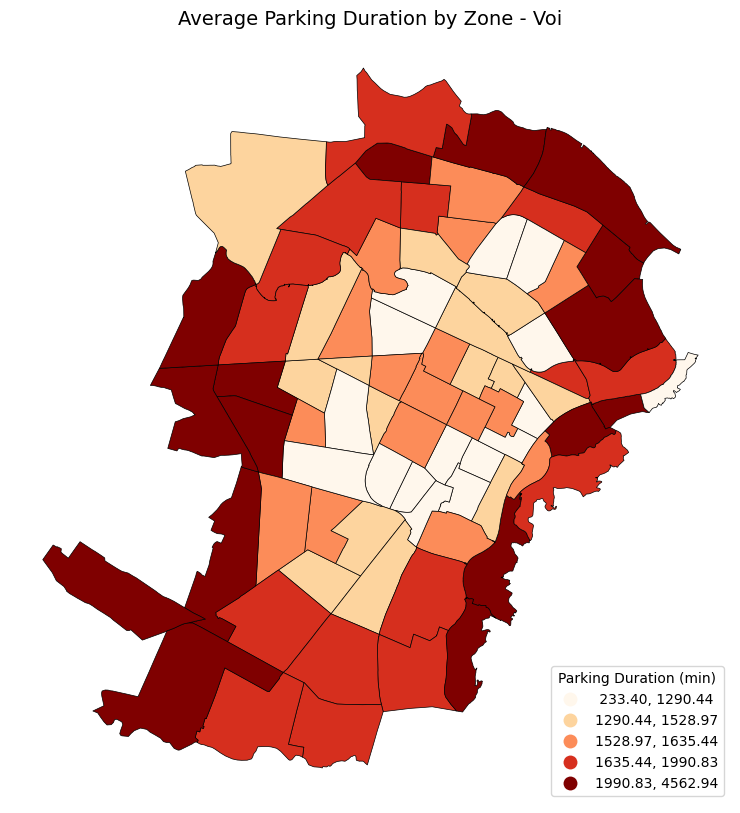

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10,10))

zones_avg.plot(
    column='parking_minutes',
    cmap='OrRd',
    scheme='quantiles',   # تقسیم به کلاس
    k=5,                  # تعداد کلاس‌ها
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'title': 'Parking Duration (min)',
        'loc': 'lower right'
    },
    ax=ax
)

ax.set_title('Average Parking Duration by Zone - Voi', fontsize=14)
ax.axis('off')

plt.show()

In [28]:
zones.total_bounds

array([ 7.57786722, 45.006773  ,  7.77338483, 45.14018759])

In [29]:
pip install folium


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
import folium

# ساخت نقشه پایه (مرکز تورین)
m = folium.Map(location=[45.07, 7.68], zoom_start=12)

# اضافه کردن choropleth
folium.Choropleth(
    geo_data=zones_avg,
    data=zones_avg,
    columns=['ZONASTAT', 'parking_minutes'],
    key_on='feature.properties.ZONASTAT',
    fill_color='OrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Average Parking Duration (minutes)'
).add_to(m)

m

In [31]:
zones_avg[zones_avg['parking_minutes'].isna()]

,ZONASTAT,DENOM,geometry,parking_minutes
5,74,Barriera di Chieri - Valpiana - Val San Martino,"MULTIPOLYGON (((7.71307 45.06413, 7.714 45.064...",NaN
9,81,Mongreno,"MULTIPOLYGON (((7.73787 45.06711, 7.73787 45.0...",NaN
10,82,Reaglie - Forni e Goffi,"MULTIPOLYGON (((7.72645 45.05927, 7.72646 45.0...",NaN
11,83,Santa Margherita,"MULTIPOLYGON (((7.70638 45.05113, 7.70676 45.0...",NaN
12,87,Cavoretto - Val Pattonera,"MULTIPOLYGON (((7.67986 45.0253, 7.67989 45.02...",NaN
82,72,Borgata Sassi - Meisino,"MULTIPOLYGON (((7.72009 45.08962, 7.72056 45.0...",NaN
83,73,Strada di Soperga,"MULTIPOLYGON (((7.72954 45.08315, 7.72969 45.0...",NaN
85,76,Villaretto,"MULTIPOLYGON (((7.65289 45.13501, 7.65381 45.1...",NaN
86,77,Falchera,"MULTIPOLYGON (((7.68654 45.11806, 7.68879 45.1...",NaN
87,78,Villaggio Snia,"MULTIPOLYGON (((7.69726 45.11414, 7.69753 45.1...",NaN


In [32]:
zones_avg.to_file("voi_parking.geojson", driver="GeoJSON")